In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
from PIL.ImageColor import colormap
from scipy import stats

from ipynb.fs.defs.functions import top_bottom, top_bottom_split_double, top_bottom_split_triple, find_outliers_iqr

In [2]:
# Einlesen
df = pd.read_csv("../data/processed/master_2024.csv", sep=",", encoding="UTF-8")
df.columns

Index(['Name', 'Typ 1', 'Typ 2', 'ROR', 'erz. Hilfen pro 10000',
       '35a Hilfen pro 10000', 'Überörtlicher Träger', 'Bevölkerung 6 bis 20',
       'Anteil Kinder a.d. Gesamtbev.', 'SGB II-Quote', 'Kinderarztdichte',
       'KJP-Dichte', 'Bildungsindex', 'Bevölkerungsdichte', 'Typ'],
      dtype='object')

In [3]:
col ="SGB II-Quote"
s = df[col]

desc = s.describe()
iqr = desc["75%"] - desc["25%"]
span = desc["max"] - desc["min"]
cv = desc["std"] / desc["mean"]

summary = {
    "mean": desc["mean"],
    "median": desc["50%"],
    "std": desc["std"],
    "IQR": iqr,
    "span": span,
    "IQR/span": iqr / span,
    "CV": cv
}

pd.Series(summary).round(3)

mean         8.451
median       7.960
std          3.293
IQR          4.670
span        14.500
IQR/span     0.322
CV           0.390
dtype: float64

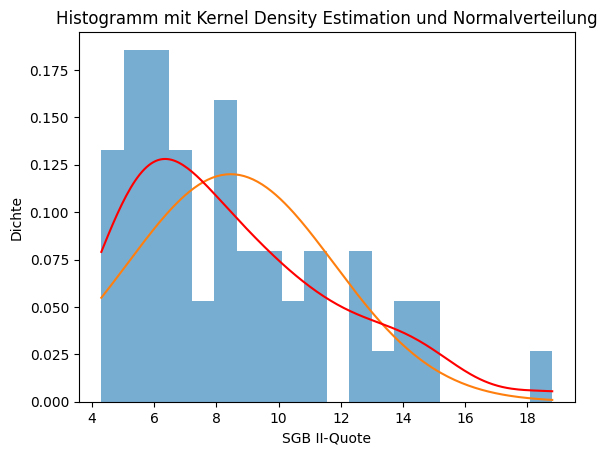

In [20]:
x = df[col].to_numpy()

plt.figure()
plt.hist(x, bins=20, density=True, alpha=0.6)

xx = np.linspace(x.min(), x.max(), 200)

mu = x.mean()
sigma = x.std(ddof=1) # Degrees fo Freedom n-1 da Strichprobe, nicht Grundgesamtheit
plt.plot(xx, stats.norm.pdf(xx, mu, sigma))

# bandwith bei stardard gelassen, o.5 liefert ähnlcihe ergebnisse, höhere werte drücken die
kde = stats.gaussian_kde(x)
plt.plot(xx, kde(xx), color="red")


plt.xlabel("SGB II-Quote")
plt.ylabel("Dichte")
plt.title("Histogramm mit Kernel Density Estimation und Normalverteilung")
plt.show()


In [5]:
mask = find_outliers_iqr(s)

df.loc[mask, ["Name", col]]

,Name,SGB II-Quote
38,Gelsenkirchen,18.8


In [6]:
# Shapefile einlesen für Kreise/ NRW
nrw = gpd.read_file("../data/NRW-map/dvg1krs_nw.shp")

# auf Übereinstimmung der Namen prüfen
set_hilfen = set(df["Name"])
set_nrw = set(nrw["GN"])
no_match = set_hilfen.symmetric_difference(set_nrw)
print(no_match)

{'Mülheim an der Ruhr', 'Städteregion Aachen', 'Aachen', 'Mülheim a.d. Ruhr'}


In [7]:
# Fehler bereinigen
mapping = {
    "Mülheim a. d. Ruhr": "Mülheim an der Ruhr",
    'Städteregion Aachen': 'Aachen'
}

nrw.loc[:, "GN"] = (
    nrw["GN"].replace(mapping)
)


# Merge GeoData mit dem DataFrame (nach Kreisname) und fehlende Werte finden
nrw = nrw.merge(df, left_on="GN", right_on="Name", how="left")  
fehlende = nrw[nrw["35a Hilfen pro 10000"].isna()]
print(fehlende[["GN"]])

                  GN
7  Mülheim a.d. Ruhr


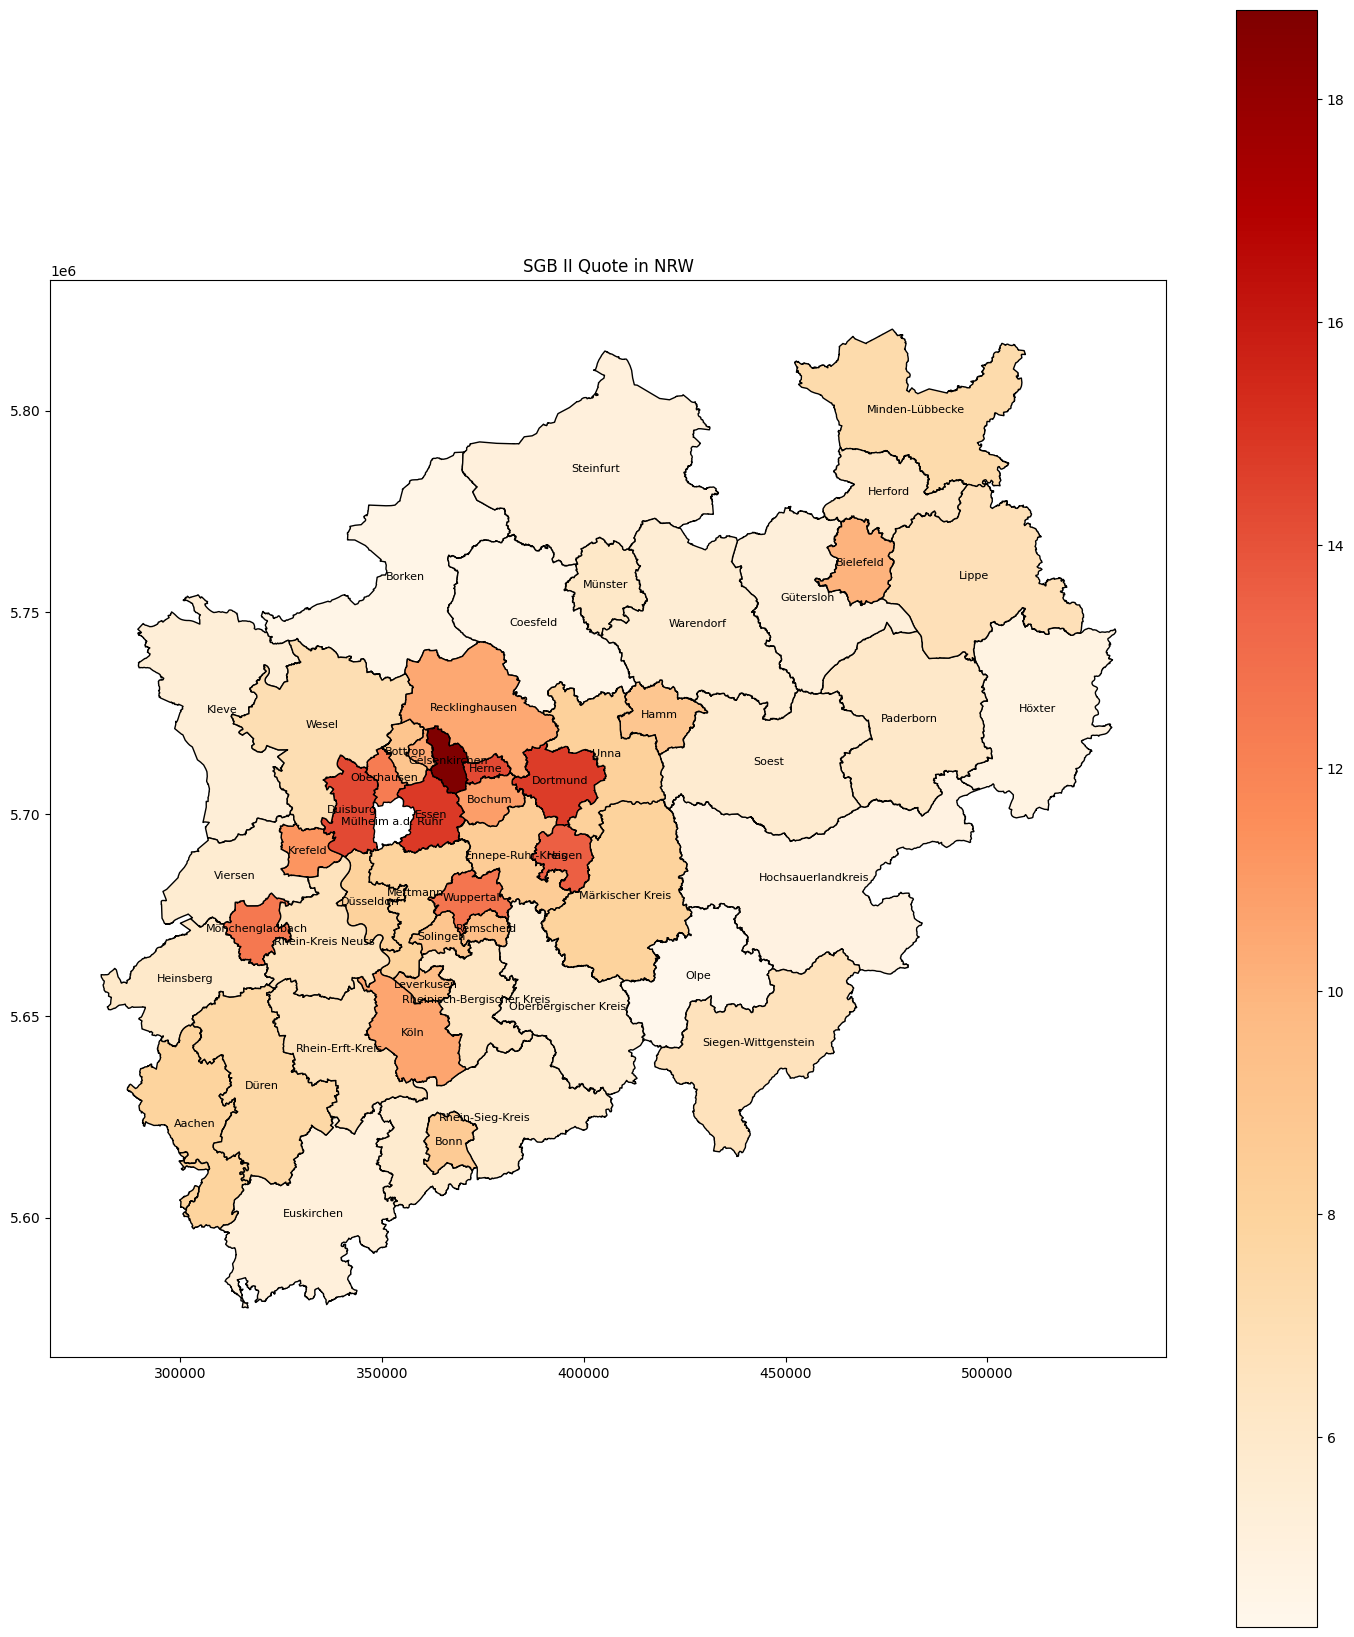

In [8]:
# Visualisierung
fig, ax = plt.subplots(1, 1, figsize=(18, 21))
nrw.plot(column=col, ax=ax, legend=True, cmap="OrRd", edgecolor="black")

for idx, row in nrw.iterrows():
    if row['geometry'].geom_type == 'Polygon':
        x, y = row['geometry'].centroid.x, row['geometry'].centroid.y
    else:  # MultiPolygon
        x, y = row['geometry'].centroid.x, row['geometry'].centroid.y
    ax.text(x, y, row['GN'], fontsize=8, ha='center', va='center')

ax.set_title("SGB II Quote in NRW")
plt.show()

In [11]:
df = df[df["Name"] != "Aachen"]

                          Name             Typ 1             Typ 2  \
0                       Borken      Großer Kreis             Kreis   
1                        Düren      Großer Kreis             Kreis   
2            Ennepe-Ruhr-Kreis      Großer Kreis             Kreis   
3                    Gütersloh      Großer Kreis             Kreis   
4                      Herford      Großer Kreis             Kreis   
5           Hochsauerlandkreis      Großer Kreis             Kreis   
6                        Lippe      Großer Kreis             Kreis   
7                     Mettmann      Großer Kreis             Kreis   
8              Minden-Lübbecke      Großer Kreis             Kreis   
9             Märkischer Kreis      Großer Kreis             Kreis   
10                   Paderborn      Großer Kreis             Kreis   
11              Recklinghausen      Großer Kreis             Kreis   
12            Rhein-Erft-Kreis      Großer Kreis             Kreis   
13           Rhein-K

In [13]:
def summary_stats(s):
    desc = s.describe()
    iqr = desc["75%"] - desc["25%"]
    span = desc["max"] - desc["min"]
    cv = desc["std"] / desc["mean"]

    return pd.Series({
        "mean": desc["mean"],
        "median": desc["50%"],
        "std": desc["std"],
        "IQR": iqr,
        "span": span,
        "IQR/span": iqr / span,
        "CV": cv
    })

summary_by_type = (
    df
    .groupby("Typ 2")[col]
    .apply(summary_stats)
    .round(3)
)

print(summary_by_type)

Typ 2                     
Kreis             mean         6.304
                  median       6.050
                  std          1.401
                  IQR          1.718
                  span         6.190
                  IQR/span     0.277
                  CV           0.222
Kreisfreie Stadt  mean        11.400
                  median      11.070
                  std          2.903
                  IQR          4.185
                  span        12.650
                  IQR/span     0.331
                  CV           0.255
Name: SGB II-Quote, dtype: float64


In [16]:
def summary_stats(s):
    desc = s.describe()
    iqr = desc["75%"] - desc["25%"]
    span = desc["max"] - desc["min"]
    cv = desc["std"] / desc["mean"]

    return pd.Series({
        "mean": desc["mean"],
        "median": desc["50%"],
        "std": desc["std"],
        "IQR": iqr,
        "span": span,
        "IQR/span": iqr / span,
        "CV": cv
    })


summary_by_type = (
    df
    .groupby("Typ 1")[col]
    .apply(summary_stats)
    .round(3)
)

print(summary_by_type)

Typ 1                     
Großer Kreis      mean         6.716
                  median       6.635
                  std          1.391
                  IQR          1.790
                  span         5.960
                  IQR/span     0.300
                  CV           0.207
Kleiner Kreis     mean         5.172
                  median       5.295
                  std          0.577
                  IQR          0.752
                  span         1.740
                  IQR/span     0.432
                  CV           0.112
Kreisfreie Stadt  mean        11.400
                  median      11.070
                  std          2.903
                  IQR          4.185
                  span        12.650
                  IQR/span     0.331
                  CV           0.255
Name: SGB II-Quote, dtype: float64


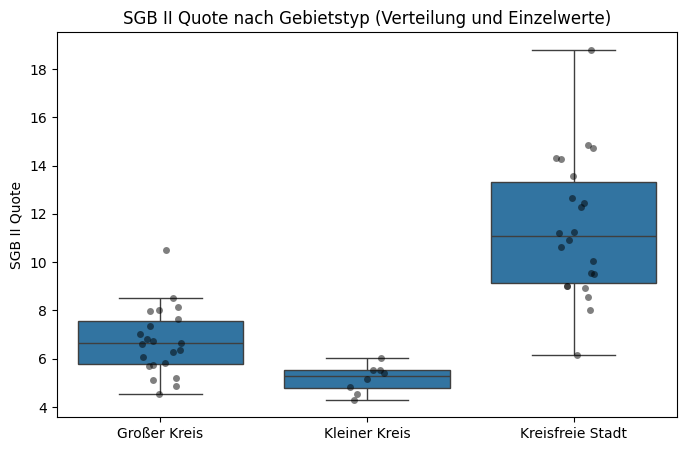

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="Typ 1",
    y=col,
    showfliers=False
)
sns.stripplot(
    data=df,
    x="Typ 1",
    y=col,
    color="black",
    alpha=0.5,
    jitter=True
)
plt.title("SGB II Quote nach Gebietstyp (Verteilung und Einzelwerte)")
plt.ylabel("SGB II Quote")
plt.xlabel("")
plt.show()

In [19]:
plt.show()
mask_by_type = (
    df
    .groupby("Typ 1")[col]
    .transform(find_outliers_iqr)
)

df.loc[mask_by_type, ["Name", "Typ 1", col]]


,Name,Typ 1,SGB II-Quote
11,Recklinghausen,Großer Kreis,10.49
